# Traning the model
Here we will train the model with out dataset.

In [118]:
%pip install -r requirements.txt
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [119]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [120]:
# 1. LOAD THE DATA
df = pd.read_csv('data/02-cleaned-data.csv')

# --- THE MAGIC TRICK ---
# Combine the two text columns into one single category. 
# Example: "Low" temp + "High" humidity becomes "Low_High"
df['Combined_Label'] = df['status_temperature'] + "_" + df['status_humidity']

print(df['Combined_Label'].head())

# Extract the input features
X = df[['temperature_celcius', 'humidity']].values

print(df.head(5))

0    Low_High
1    Low_High
2    Low_High
3    Low_High
4    Low_High
Name: Combined_Label, dtype: str
   Unnamed: 0  humidity  temperature_celcius status_temperature  \
0           0      78.0                 23.0                Low   
1           1      78.0                 23.9                Low   
2           2      78.0                 23.9                Low   
3           3      78.0                 23.9                Low   
4           4      78.0                 23.9                Low   

  status_humidity Combined_Label  
0            High       Low_High  
1            High       Low_High  
2            High       Low_High  
3            High       Low_High  
4            High       Low_High  


In [121]:
# 2. ENCODE THE TEXT TO NUMBERS
encoder = LabelEncoder()
# This turns your text like "Low_High" into an integer like 0, 1, 2, etc.
y = encoder.fit_transform(df['Combined_Label'])

print("\nClasses the model will learn:")
for index, label in enumerate(encoder.classes_):
    print(f"Class {index}: {label}")


Classes the model will learn:
Class 0: High_High
Class 1: High_Low
Class 2: Low_High
Class 3: Low_Low


In [122]:
# 3. PREPROCESS THE DATA
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Find out how many unique combinations we created
num_classes = len(encoder.classes_)
print(f"Number of unique classes: {num_classes}")

Number of unique classes: 4


In [123]:
X_train, X_test, y_train, y_test 

(array([[0.42647059, 0.11111111],
        [0.13235294, 0.44444444],
        [0.42647059, 0.11111111],
        ...,
        [0.48529412, 0.96296296],
        [0.73529412, 0.44444444],
        [0.13235294, 0.44444444]], shape=(684, 2)),
 array([[0.13235294, 0.44444444],
        [0.73529412, 0.44444444],
        [0.08823529, 0.44444444],
        [0.01470588, 0.44444444],
        [0.33823529, 0.11111111],
        [0.55882353, 0.03703704],
        [0.72058824, 0.96296296],
        [0.69117647, 1.        ],
        [0.89705882, 0.92592593],
        [0.19117647, 0.14814815],
        [0.41176471, 0.07407407],
        [0.45588235, 0.03703704],
        [0.36764706, 0.07407407],
        [0.83823529, 1.        ],
        [0.76470588, 1.        ],
        [0.67647059, 0.03703704],
        [0.76470588, 0.37037037],
        [0.44117647, 0.03703704],
        [0.88235294, 0.55555556],
        [0.14705882, 0.18518519],
        [0.13235294, 0.44444444],
        [0.51470588, 0.        ],
        [0.455882

In [124]:
# 4. BUILD THE NEURAL NETWORK
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(2,)), 
    tf.keras.layers.Dense(8, activation='relu'),                   
    # The output layer matches the exact number of our combined classes
    tf.keras.layers.Dense(num_classes, activation='softmax')                 
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

/home/rownak/Documents/projects/hotOrColdTinyML/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [125]:
# 5. TRAIN THE MODEL
print("\n--- Starting Training ---")
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))


--- Starting Training ---
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2851 - loss: 1.3013 - val_accuracy: 0.4912 - val_loss: 1.2633
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6009 - loss: 1.2485 - val_accuracy: 0.6374 - val_loss: 1.2210
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6345 - loss: 1.2072 - val_accuracy: 0.6257 - val_loss: 1.1844
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6287 - loss: 1.1681 - val_accuracy: 0.6140 - val_loss: 1.1459
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6243 - loss: 1.1269 - val_accuracy: 0.6023 - val_loss: 1.1060
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6126 - loss: 1.0862 - val_accuracy: 0.6023 - val_loss: 1.0663
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6213 - loss: 1.0449 - val_accuracy: 0.6023 - val_loss: 1.0243
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6213 - loss: 1.0024

In [126]:
# 6. TEST THE MODEL
print("\n--- Testing Model on Unseen Data ---")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")


--- Testing Model on Unseen Data ---


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9591 - loss: 0.1208 
Model Accuracy: 95.91%


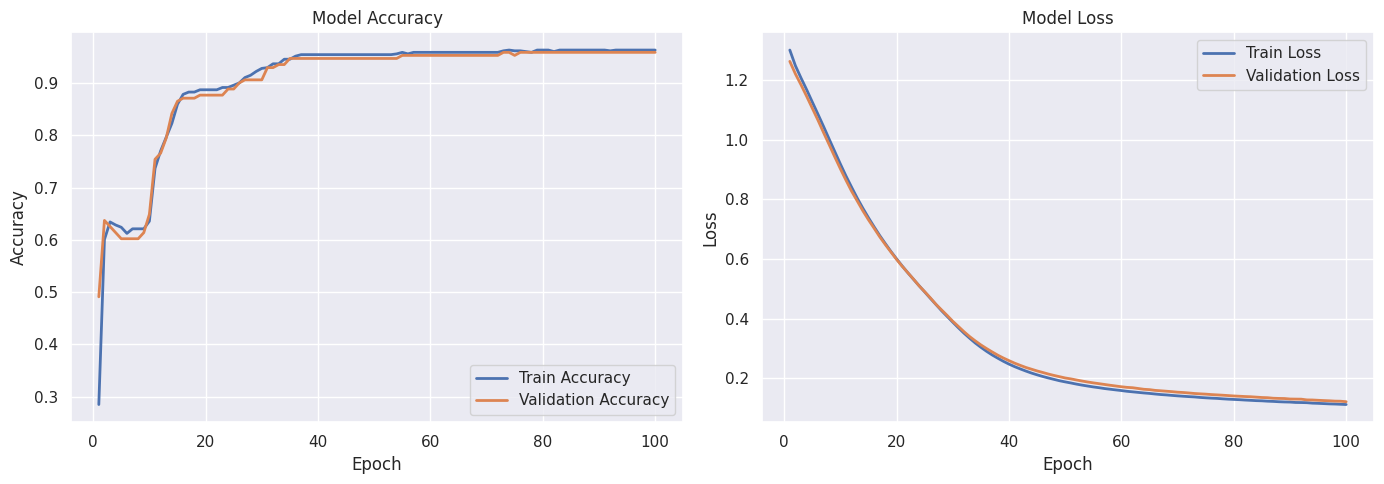

In [127]:
# Set the visual style for Seaborn
sns.set_theme(style="darkgrid")

# Convert the history dictionary into a Pandas DataFrame
history_df = pd.DataFrame(history.history)
# Add an 'epoch' column starting at 1
history_df['epoch'] = history_df.index + 1

# Create a wide figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy ---
sns.lineplot(data=history_df, x='epoch', y='accuracy', label='Train Accuracy', ax=axes[0], linewidth=2)
sns.lineplot(data=history_df, x='epoch', y='val_accuracy', label='Validation Accuracy', ax=axes[0], linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# --- Plot 2: Loss ---
sns.lineplot(data=history_df, x='epoch', y='loss', label='Train Loss', ax=axes[1], linewidth=2)
sns.lineplot(data=history_df, x='epoch', y='val_loss', label='Validation Loss', ax=axes[1], linewidth=2)
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()

### Converting the model to TensorFlow Lite format

**CONVERT THE MODEL**

We use the built-in converter to transform your Keras model into TFLite format

In [131]:

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimize for size (Crucial for TinyML!)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save the binary .tflite file just in case you need it later
with open("model/model.tflite", "wb") as f:
    f.write(tflite_model)
    
print(f"Model successfully converted! Size: {len(tflite_model)} bytes")

INFO:tensorflow:Assets written to: /tmp/tmpsnmwj9g1/assets


INFO:tensorflow:Assets written to: /tmp/tmpsnmwj9g1/assets


Saved artifact at '/tmp/tmpsnmwj9g1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2), dtype=tf.float32, name='keras_tensor_36')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  127525637448976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127525637446864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127525637446672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127525637449744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127525637447056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127525637446096: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model successfully converted! Size: 2680 bytes


W0000 00:00:1772648848.613494    3859 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772648848.613508    3859 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-04 19:27:28.613606: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpsnmwj9g1
2026-03-04 19:27:28.613888: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-04 19:27:28.613892: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpsnmwj9g1
2026-03-04 19:27:28.616342: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-03-04 19:27:28.631462: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpsnmwj9g1
2026-03-04 19:27:28.636395: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 22790 microseconds.


**CREATE THE C-BYTE ARRAY**

This function takes the raw binary data and turns it into C++ code

In [132]:

def hex_to_c_array(hex_data, var_name):
    c_str = ''
    # Create the array declaration
    c_str += f'// Auto-generated by Colab\n'
    c_str += f'const unsigned char {var_name}[] = {{\n'
    hex_array = []
    
    for i, val in enumerate(hex_data):
        # Format as 0x00
        hex_str = hex(val)
        if len(hex_str) == 3:
            hex_str = '0x0' + hex_str[2]
        hex_array.append(hex_str)
        
    # Format with 12 bytes per line so it looks neat
    for i in range(0, len(hex_array), 12):
        c_str += '  ' + ', '.join(hex_array[i:i+12]) + ',\n'
        
    c_str += '};\n\n'
    c_str += f'const int {var_name}_len = {len(hex_data)};\n'
    return c_str

**SAVE THE HEADER FILE**

In [133]:
c_code = hex_to_c_array(tflite_model, "model_tflite")

with open("model/model.h", "w") as f:
    f.write(c_code)

print("\nSuccess! Saved as 'model.h'.")


Success! Saved as 'model.h'.
